In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy import stats
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, auc, average_precision_score
)
from sklearn.model_selection import train_test_split
from scipy.stats import ttest_rel, wilcoxon
import warnings
warnings.filterwarnings('ignore')

import os

os.makedirs('charts', exist_ok=True)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("✓ All imports successful")


RANDOM_STATE = 42  
pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")


✓ All imports successful


In [39]:
# Column names
column_names = [
"age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

dataset = fetch_openml('adult', version=2, as_frame=True)
df = dataset.frame

df.replace('?', np.nan, inplace=True)

print("Shape:", df.shape)
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [40]:
df.rename(columns={'class': 'income'}, inplace=True)

# Converts the target to binary.
df["income"] = df["income"].str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

df[["income", "target"]].drop_duplicates()
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,0


In [41]:
# Numeric summaries
numeric_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
df[numeric_cols].describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [42]:
# base rate
base_rate = df["target"].mean()
class_counts = df["target"].value_counts().rename({0: "<=50K", 1: ">50K"})
print(class_counts)
print(f"\nBase rate (positive class share): {base_rate}")


target
<=50K    37155
>50K     11687
Name: count, dtype: int64

Base rate (positive class share): 0.23928176569346055


In [43]:
# 80% train+dev / 20% hold-out test, stratified on the target
train_dev_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["target"], random_state=RANDOM_STATE
)

train_df, dev_df = train_test_split(
    train_dev_df, test_size=0.125, stratify=train_dev_df["target"], random_state=RANDOM_STATE
)

print(f"Train size: {len(train_df)}  ({len(train_df)/len(df)} of full data)")
print(f"Dev size:   {len(dev_df)}   ({len(dev_df)/len(df)} of full data)")
print(f"Test size:  {len(test_df)}  ({len(test_df)/len(df)} of full data)")
print()
print("Class balance check (share of positives in each split):")
for name, part in [("Full data", df), ("Train", train_df), ("Dev", dev_df), ("Test (hold-out)", test_df)]:
    print(f"  {name:18s}: {part['target'].mean()}")


Train size: 34188  (0.699971336145121 of full data)
Dev size:   4885   (0.10001637934564514 of full data)
Test size:  9769  (0.20001228450923386 of full data)

Class balance check (share of positives in each split):
  Full data         : 0.23928176569346055
  Train             : 0.23926523926523927
  Dev               : 0.23930399181166837
  Test (hold-out)   : 0.23932848807452145


In [44]:
def evaluate(y_true, y_pred, y_score, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }

#### Defining Numeric and Categorical Columns

In [45]:
# df.head(10)

categorical_cols = ["workclass", "marital-status", "occupation", "relationship",
                         "race", "sex", "native-country"]

# combined feautres
feature_cols = numeric_cols + categorical_cols

# Train and test data
X_train, y_train = train_df[feature_cols], train_df["target"]
X_dev,   y_dev = dev_df[feature_cols],   dev_df["target"]
X_test_feature = test_df[feature_cols]
y_test = test_df['target'].values

## Task 1: Engineered Features

In [46]:
AGE_BINS = [0, 25, 35, 45, 55, 65, 100]
AGE_LABELS = ["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]

HOURS_BINS = [0, 20, 35, 40, 50, 100]
HOURS_LABELS = ["part_time_le20", "reduced_21_35", "standard_36_40", "over_41_50", "heavy_50plus"]

def engineer_features(frame):
    new_fe = frame.copy()

    new_fe["age_bucket"] = pd.cut(new_fe["age"], bins=AGE_BINS, labels=AGE_LABELS, right=True).astype(str)
    new_fe["hours_bucket"] = pd.cut(new_fe["hours-per-week"], bins=HOURS_BINS, labels=HOURS_LABELS, right=True).astype(str)

    new_fe["has_capital_gain"] = (new_fe["capital-gain"] > 0).astype(int)
    new_fe["has_capital_loss"] = (new_fe["capital-loss"] > 0).astype(int)
    new_fe["higher_education"] = (new_fe["education-num"] >= 13).astype(int)

    new_fe["log_capital_gain"] = np.log1p(new_fe["capital-gain"])
    new_fe["edu_hours_interaction"] = new_fe["education-num"] * new_fe["hours-per-week"]
    new_fe["net_capital"] = new_fe["capital-gain"] - new_fe["capital-loss"]

    return new_fe

df_eng = engineer_features(train_df)

print("✓ Features engineered successfully")
print(f"\nNew feature count: {len(df_eng.columns) - len(df.columns)}")
print(f"Total features: {df_eng.shape[1]}")

✓ Features engineered successfully

New feature count: 8
Total features: 24


## Feature Justification Summary

#### Feature  Justification 
age_bucket  Non-linear age effect: income rises then plateaus, better captured by bins than raw age 
hours_bucket  Part-time, standard, and overtime work have distinct, non-linear pay relationships 
has_capital_gain  Capital gains behave as a threshold signal, not continuous presence matters more than amount 
has_capital_loss  Any recorded investment loss signals investment activity and financial sophistication 
higher_education  Bachelors degree or higher is a natural, interpretable cutoff for earning potential 
log_capital_gain  Log transformation compresses extreme right tail, improving tree splits and model stability 
edu_hours_interaction  Highly educated people working long hours earn disproportionately more (compounding effect) 
net_capital  Nets gains and losses into one investment-activity signal instead of two separate columns 

In [47]:
new_num_fe = ["log_capital_gain", "edu_hours_interaction", "net_capital"]
new_bol_fe = ["has_capital_gain", "has_capital_loss", "higher_education"]
new_cat_fe = ["age_bucket", "hours_bucket"]

mi_scores = {}

# Mutual info 
for col in new_num_fe + new_bol_fe:
    is_discrete = col in new_bol_fe
    mi = mutual_info_classif(
        df_eng[[col]], df_eng["target"],
        discrete_features=[is_discrete], random_state=RANDOM_STATE
    )
    mi_scores[col] = mi[0]


# Mutual info for categories
for col in new_cat_fe:
    dummies = pd.get_dummies(df_eng[col])
    mi = mutual_info_classif(dummies, df_eng["target"], discrete_features=True, random_state=RANDOM_STATE)
    mi_scores[col] = mi.sum()

print("Mutual information scores:")
for name, score in sorted(mi_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:24s}: {score:.4f}")
  
print("\nGrouped mean of target by age_bucket:")
print(df_eng.groupby("age_bucket")["target"].mean().reindex(AGE_LABELS))

print("\nGrouped mean of target by hours_bucket:")
print(df_eng.groupby("hours_bucket")["target"].mean().reindex(HOURS_LABELS))

Mutual information scores:
  net_capital             : 0.1196
  edu_hours_interaction   : 0.0816
  log_capital_gain        : 0.0799
  age_bucket              : 0.0723
  higher_education        : 0.0488
  hours_bucket            : 0.0428
  has_capital_gain        : 0.0291
  has_capital_loss        : 0.0085

Grouped mean of target by age_bucket:
age_bucket
<=25     0.018122
26-35    0.186233
36-45    0.347341
46-55    0.388039
56-65    0.316041
65+      0.191943
Name: target, dtype: float64

Grouped mean of target by hours_bucket:
hours_bucket
part_time_le20    0.074694
reduced_21_35     0.096248
standard_36_40    0.209037
over_41_50        0.390973
heavy_50plus      0.407915
Name: target, dtype: float64


In [48]:
# Feature dictionary
feature_dict = pd.DataFrame([
    {"name": "age_bucket", "type": "categorical (binned)",
     "creation_rule": "pd.cut(age, fixed bins [0,25,35,45,55,65,100])",
     "justification": "Income rises then plateaus with age, a non-monotonic pattern a linear term on raw age cannot capture",
     "mi_score": mi_scores["age_bucket"]},
    {"name": "hours_bucket", "type": "categorical (binned)",
     "creation_rule": "pd.cut(hours-per-week, fixed bins [0,20,35,40,50,100])",
     "justification": "Part time, standard, and overtime work likely have distinct, non-linear pay relationships",
     "mi_score": mi_scores["hours_bucket"]},
    {"name": "has_capital_gain", "type": "binary flag",
     "creation_rule": "capital-gain > 0",
     "justification": "Day 2 found capital-gain behaves like a threshold signal, not a continuous one, this isolates that",
     "mi_score": mi_scores["has_capital_gain"]},
    {"name": "has_capital_loss", "type": "binary flag",
     "creation_rule": "capital-loss > 0",
     "justification": "Same threshold logic as capital gain, any recorded loss may signal investment activity",
     "mi_score": mi_scores["has_capital_loss"]},
    {"name": "higher_education", "type": "binary flag",
     "creation_rule": "education-num >= 13",
     "justification": "A Bachelor's degree or higher is a natural, interpretable cutoff instead of a raw ordinal count",
     "mi_score": mi_scores["higher_education"]},
    {"name": "log_capital_gain", "type": "numeric transform",
     "creation_rule": "log1p(capital-gain)",
     "justification": "Compresses the extreme right tail, useful for tree splits even though it hurt raw scaled LogReg on Day 2",
     "mi_score": mi_scores["log_capital_gain"]},
    {"name": "edu_hours_interaction", "type": "numeric interaction",
     "creation_rule": "education-num * hours-per-week",
     "justification": "Captures a compounding effect, highly educated people working long hours may earn disproportionately more",
     "mi_score": mi_scores["edu_hours_interaction"]},
    {"name": "net_capital", "type": "numeric",
     "creation_rule": "capital-gain - capital-loss",
     "justification": "Nets gains and losses into one investment-activity signal instead of two separate columns",
     "mi_score": mi_scores["net_capital"]},
]).sort_values("mi_score", ascending=False).reset_index(drop=True)

feature_dict

,name,type,creation_rule,justification,mi_score
0,net_capital,numeric,capital-gain - capital-loss,Nets gains and losses into one investment-acti...,0.119564
1,edu_hours_interaction,numeric interaction,education-num * hours-per-week,"Captures a compounding effect, highly educated...",0.081588
2,log_capital_gain,numeric transform,log1p(capital-gain),"Compresses the extreme right tail, useful for ...",0.079856
3,age_bucket,categorical (binned),"pd.cut(age, fixed bins [0,25,35,45,55,65,100])","Income rises then plateaus with age, a non-mon...",0.072318
4,higher_education,binary flag,education-num >= 13,"A Bachelor's degree or higher is a natural, in...",0.048813
5,hours_bucket,categorical (binned),"pd.cut(hours-per-week, fixed bins [0,20,35,40,...","Part time, standard, and overtime work likely ...",0.042838
6,has_capital_gain,binary flag,capital-gain > 0,Day 2 found capital-gain behaves like a thresh...,0.029113
7,has_capital_loss,binary flag,capital-loss > 0,"Same threshold logic as capital gain, any reco...",0.008502


In [49]:
all_numeric_cols = numeric_cols + ["log_capital_gain", "edu_hours_interaction", "net_capital"]
all_bol_cols = ["has_capital_gain", "has_capital_loss", "higher_education"]
all_cat_cols = categorical_cols + ["age_bucket", "hours_bucket"]

numeric_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

binary_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

categorical_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor_fe = ColumnTransformer([
    ("num", numeric_pipeline_fe, all_numeric_cols),
    ("bin", binary_pipeline_fe, all_bol_cols),
    ("cat", categorical_pipeline_fe, all_cat_cols),
])

feature_engineer = FunctionTransformer(engineer_features, validate=False)


X_train_fe_input = train_df[feature_cols]
X_dev_fe_input = dev_df[feature_cols]
X_test_fe_input = test_df[feature_cols]

print("Engineered pipeline input columns:", list(X_train_fe_input.columns))
print("\nNumber of one hot encoder + numeric + bool cols after processing:")
sample_transformed = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
]).fit_transform(X_train_fe_input, y_train)
print(sample_transformed.shape)

Engineered pipeline input columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Number of one hot encoder + numeric + bool cols after processing:
(34188, 106)


In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

selected_models = {
    "Logistic Regression": LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_results = {}
cv_summary_rows_data = []

for name, clf in selected_models.items():
    pipe = Pipeline([
        ("feature_engineering", feature_engineer),
        ("preprocessing", preprocessor_fe),
        ("clf", clf),
    ])

    # time calculation it took to run
    start = time.time()
    scores = cross_validate(pipe, X_train_fe_input, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - start

    cv_results[name] = scores
    cv_summary_rows_data.append({
    "model": name,
    "precision_mean": scores["test_precision"].mean(),
    "precision_std": scores["test_precision"].std(),
    "recall_mean": scores["test_recall"].mean(),
    "recall_std": scores["test_recall"].std(),
    "f1_mean": scores["test_f1"].mean(),
    "f1_std": scores["test_f1"].std(),
    "roc_auc_mean": scores["test_roc_auc"].mean(),
    "roc_auc_std": scores["test_roc_auc"].std(),
    "fit_time_sec": elapsed,
})
    print(
    f"{name:30s} "
    f"Precision = {scores['test_precision'].mean()} +- {scores['test_precision'].std()} | "
    f"Recall = {scores['test_recall'].mean()} +- {scores['test_recall'].std()} | "
    f"F1 = {scores['test_f1'].mean()} +- {scores['test_f1'].std()} | "
    f"ROC AUC = {scores['test_roc_auc'].mean()} +- {scores['test_roc_auc'].std()} | "
    f"{elapsed}s"
)


cv_summary_df = pd.DataFrame(cv_summary_rows_data).set_index("model").round(4)
cv_summary_df

Logistic Regression            Precision = 0.7436443081744454 +- 0.007580525420807251 | Recall = 0.6096577017114914 +- 0.007217892136491703 | F1 = 0.6699704779497162 +- 0.004803649876372113 | ROC AUC = 0.9126942422028181 +- 0.003330970987415366 | 9.860726356506348s
Random Forest                  Precision = 0.7288444777937689 +- 0.010400912683565976 | Recall = 0.6202933985330075 +- 0.0048960842040344345 | F1 = 0.6701634246092781 +- 0.005601204414397978 | ROC AUC = 0.906491441231533 +- 0.0026962369305459895 | 33.36776375770569s
Gradient Boosting Classifier   Precision = 0.7813475007542602 +- 0.008984376098865704 | Recall = 0.6008557457212713 +- 0.009041497353105424 | F1 = 0.6792701084896049 +- 0.0072835260606089304 | ROC AUC = 0.9202863624544054 +- 0.0036157032335599466 | 48.13713574409485s


,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,fit_time_sec
model,,,,,,,,,
Logistic Regression,0.7436,0.0076,0.6097,0.0072,0.6700,0.0048,0.9127,0.0033,9.8607
Random Forest,0.7288,0.0104,0.6203,0.0049,0.6702,0.0056,0.9065,0.0027,33.3678
Gradient Boosting Classifier,0.7813,0.0090,0.6009,0.0090,0.6793,0.0073,0.9203,0.0036,48.1371


Visualize

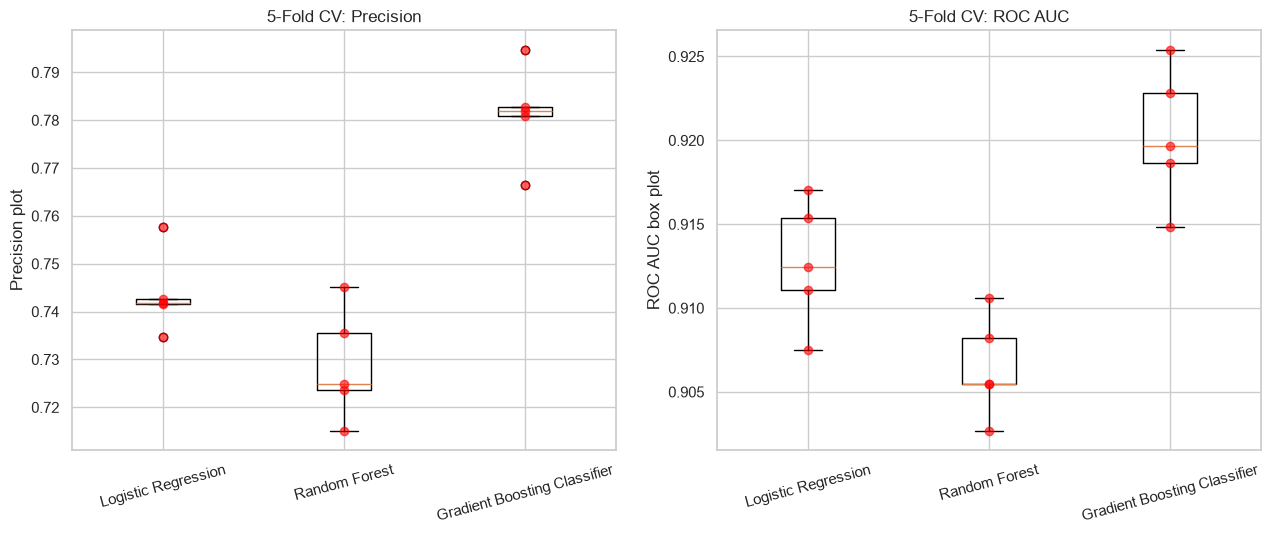

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
model_names = list(selected_models.keys())

# Precision
for i, name in enumerate(model_names):
    y_precision = cv_results[name]["test_precision"]
    axes[0].scatter(
        [i + 1] * len(y_precision),
        y_precision,
        color="red",
        alpha=0.6,
        zorder=3,
    )

# ROC AUC 
for i, name in enumerate(model_names):
    y_auc = cv_results[name]["test_roc_auc"]
    axes[1].scatter(
        [i + 1] * len(y_auc),
        y_auc,
        color="red",
        alpha=0.6,
        zorder=3,
    )

# Precision boxplot
axes[0].boxplot([cv_results[name]["test_precision"] for name in model_names])
axes[0].set_xticks(range(1, len(model_names) + 1))
axes[0].set_xticklabels(model_names, rotation=15)
axes[0].set_ylabel("Precision plot")
axes[0].set_title("5-Fold CV: Precision")

# ROC AUC boxplot
axes[1].boxplot([cv_results[name]["test_roc_auc"] for name in model_names])
axes[1].set_xticks(range(1, len(model_names) + 1))
axes[1].set_xticklabels(model_names, rotation=15)
axes[1].set_ylabel("ROC AUC box plot")
axes[1].set_title("5-Fold CV: ROC AUC")

plt.tight_layout()
plt.savefig("charts/boxplot.png")
plt.show()

In [52]:
precision_scores_by_model = {
    name: cv_results[name]["test_precision"]
    for name in selected_models
}

mean_precision = {
    name: scores.mean()
    for name, scores in precision_scores_by_model.items()
}

ranked_models = sorted(
    mean_precision,
    key=mean_precision.get,
    reverse=True,
)

top_1st, top_2nd = ranked_models[0], ranked_models[1]

print(f"Top model by mean Precision: {top_1st} ({mean_precision[top_1st]})")
print(f"Runner-up by mean Precision: {top_2nd} ({mean_precision[top_2nd]})")
print(f"Raw mean difference:         {mean_precision[top_1st] - mean_precision[top_2nd]}")

t_stat, p_value_t = stats.ttest_rel(
    precision_scores_by_model[top_1st],
    precision_scores_by_model[top_2nd],
)

w_stat, p_value_w = stats.wilcoxon(
    precision_scores_by_model[top_1st],
    precision_scores_by_model[top_2nd],
)

print(f"Paired ttest: t = {t_stat}, p = {p_value_t}")
print(f"Wilcoxon test: W = {w_stat}, p = {p_value_w}")

Top model by mean Precision: Gradient Boosting Classifier (0.7813475007542602)
Runner-up by mean Precision: Logistic Regression (0.7436443081744454)
Raw mean difference:         0.037703192579814804
Paired ttest: t = 10.527074394572312, p = 0.0004605064007724456
Wilcoxon test: W = 0.0, p = 0.0625


In [53]:
# full pipeline 
fitted_pipelines = {}
for name, clf in selected_models.items():
    pipe = Pipeline([
        ("feature_engineering", feature_engineer),
        ("preprocessing", preprocessor_fe),
        ("clf", clf),
    ])
    pipe.fit(X_train_fe_input, y_train)
    fitted_pipelines[name] = pipe

feature_names_fe = fitted_pipelines["Logistic Regression"].named_steps["preprocessing"].get_feature_names_out()

logreg_coefs = fitted_pipelines["Logistic Regression"].named_steps["clf"].coef_[0]
logreg_coef_df = pd.DataFrame({"feature": feature_names_fe, "coefficient": logreg_coefs})

engineered_feature_prefixes = ("num__log_capital_gain", "num__edu_hours_interaction", "num__net_capital",
                                "bin__has_capital_gain", "bin__has_capital_loss", "bin__higher_education",
                                "cat__age_bucket", "cat__hours_bucket")
engineered_mask = logreg_coef_df["feature"].str.startswith(engineered_feature_prefixes)
print("Logistic Regression coefficients for engineered features only:")
display(logreg_coef_df[engineered_mask].sort_values("coefficient", ascending=False))

for tree_model_name in ["Random Forest"]:
    importances = fitted_pipelines[tree_model_name].named_steps["clf"].feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names_fe, "importance": importances})
    imp_mask = imp_df["feature"].str.startswith(engineered_feature_prefixes)
    print(f"\n{tree_model_name} feature importances for new features:")
    display(imp_df[imp_mask].sort_values("importance", ascending=False))

Logistic Regression coefficients for engineered features only:


,feature,coefficient
8,num__net_capital,1.900654
96,cat__age_bucket_36-45,0.427566
97,cat__age_bucket_46-55,0.424839
102,cat__hours_bucket_over_41_50,0.390840
101,cat__hours_bucket_heavy_50plus,0.286462
6,num__log_capital_gain,0.262992
11,bin__higher_education,0.116314
95,cat__age_bucket_26-35,0.040649
98,cat__age_bucket_56-65,-0.010978
105,cat__hours_bucket_standard_36_40,-0.021807



Random Forest feature importances for new features:


,feature,importance
7,num__edu_hours_interaction,0.080822
8,num__net_capital,0.051672
6,num__log_capital_gain,0.037640
11,bin__higher_education,0.027013
9,bin__has_capital_gain,0.010896
100,cat__age_bucket_<=25,0.010087
97,cat__age_bucket_46-55,0.008496
96,cat__age_bucket_36-45,0.008082
102,cat__hours_bucket_over_41_50,0.006593
95,cat__age_bucket_26-35,0.006537


In [54]:
best_model = ranked_models[0]
best_clf = selected_models[best_model]

k_value = 60

pipe_full = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
    ("clf", best_clf),
])

pipe_selected = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
    ("select", SelectKBest(score_func=mutual_info_classif, k=k_value)),
    ("clf", best_clf),
])

results_compare = {}

for label, pipe in [
    ("features", pipe_full),
    (f"Select K-Best (k={k_value})", pipe_selected),
]:

    start = time.time()

    scores = cross_validate(
        pipe,
        X_train_fe_input,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    elapsed = time.time() - start

    results_compare[label] = {
        "precision_mean": scores["test_precision"].mean(),
        "precision_std": scores["test_precision"].std(),
        "recall_mean": scores["test_recall"].mean(),
        "recall_std": scores["test_recall"].std(),
        "f1_mean": scores["test_f1"].mean(),
        "f1_std": scores["test_f1"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "total_fit_time_sec": elapsed,
    }

    print(
        f"{label:30s} "
        f"Precision = {scores['test_precision'].mean()} +/- {scores['test_precision'].std()} | "
        f"Recall = {scores['test_recall'].mean()} +/- {scores['test_recall'].std()} | "
        f"F1 = {scores['test_f1'].mean()} +/- {scores['test_f1'].std()} | "
        f"ROC AUC = {scores['test_roc_auc'].mean()} | "
        f"Time = {elapsed}'s"
    )

pd.DataFrame(results_compare).round(4)

features                       Precision = 0.7813475007542602 +/- 0.008984376098865704 | Recall = 0.6008557457212713 +/- 0.009041497353105424 | F1 = 0.6792701084896049 +/- 0.0072835260606089304 | ROC AUC = 0.9202863624544054 | Time = 48.94584608078003's
Select K-Best (k=60)           Precision = 0.7823494461024134 +/- 0.01060557906221784 | Recall = 0.5992665036674817 +/- 0.007259184762495595 | F1 = 0.6786161350540557 +/- 0.005704344094233175 | ROC AUC = 0.9195750948113307 | Time = 41.84490203857422's


,features,Select K-Best (k=60)
precision_mean,0.7813,0.7823
precision_std,0.0090,0.0106
recall_mean,0.6009,0.5993
recall_std,0.0090,0.0073
f1_mean,0.6793,0.6786
f1_std,0.0073,0.0057
roc_auc_mean,0.9203,0.9196
total_fit_time_sec,48.9458,41.8449


In [55]:
final_features_to_keep = {
    "raw_numeric": numeric_cols,
    "raw_categorical": categorical_cols,
    "engineered": ["age_bucket", "hours_bucket", "has_capital_gain", "has_capital_loss",
                   "higher_education", "log_capital_gain", "edu_hours_interaction", "net_capital"],
}

for group, feats in final_features_to_keep.items():
    print(f"{group} ({len(feats)}):")
    for f in feats:
        print(f"  - {f}")
    print()

total_features = sum(len(v) for v in final_features_to_keep.values())
print(f"features kept: {total_features}")

raw_numeric (6):
  - age
  - fnlwgt
  - education-num
  - capital-gain
  - capital-loss
  - hours-per-week

raw_categorical (7):
  - workclass
  - marital-status
  - occupation
  - relationship
  - race
  - sex
  - native-country

engineered (8):
  - age_bucket
  - hours_bucket
  - has_capital_gain
  - has_capital_loss
  - higher_education
  - log_capital_gain
  - edu_hours_interaction
  - net_capital

features kept: 21
